In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [37]:
df = pd.read_csv("cricket1.csv")

In [38]:
df.head()

,Outlook,Temperature,Humidity,Windy,Play Cricket
0,Sunny,Hot,High,False,No
1,Sunny,Hot,High,True,No
2,Overcast,Hot,High,False,Yes
3,Rainy,Mild,High,False,Yes
4,Rainy,Cool,Normal,False,Yes


In [39]:
from sklearn.preprocessing import LabelEncoder

In [40]:
le = LabelEncoder()

In [41]:
df.columns

Index(['Outlook', 'Temperature', 'Humidity', 'Windy', 'Play Cricket'], dtype='object')

In [42]:
df['Outlook_n'] = le.fit_transform(df['Outlook'])
df['Temperature_n'] = le.fit_transform(df['Temperature'])
df['Humidity_n'] = le.fit_transform(df['Humidity'])
df['Windy_n'] = le.fit_transform(df['Windy'])
df['Play_Cricket_n'] = le.fit_transform(df['Play Cricket'])

In [43]:
df.head()

,Outlook,Temperature,Humidity,Windy,Play Cricket,Outlook_n,Temperature_n,Humidity_n,Windy_n,Play_Cricket_n
0,Sunny,Hot,High,False,No,2,1,0,0,0
1,Sunny,Hot,High,True,No,2,1,0,1,0
2,Overcast,Hot,High,False,Yes,0,1,0,0,1
3,Rainy,Mild,High,False,Yes,1,2,0,0,1
4,Rainy,Cool,Normal,False,Yes,1,0,1,0,1


In [44]:
df = df.drop(['Outlook', 'Temperature', 'Humidity', 'Windy', 'Play Cricket'], axis=1)

In [45]:
df

,Outlook_n,Temperature_n,Humidity_n,Windy_n,Play_Cricket_n
0,2,1,0,0,0
1,2,1,0,1,0
2,0,1,0,0,1
3,1,2,0,0,1
4,1,0,1,0,1
5,1,0,1,1,0
6,0,0,1,1,1
7,2,2,0,0,0
8,2,0,1,0,1
9,1,2,1,0,1


In [46]:
x = df.drop(['Play_Cricket_n'], axis = 1)

In [47]:
x

,Outlook_n,Temperature_n,Humidity_n,Windy_n
0,2,1,0,0
1,2,1,0,1
2,0,1,0,0
3,1,2,0,0
4,1,0,1,0
5,1,0,1,1
6,0,0,1,1
7,2,2,0,0
8,2,0,1,0
9,1,2,1,0


In [48]:
y = df['Play_Cricket_n']

In [49]:
from sklearn.tree import DecisionTreeClassifier

In [50]:
model = DecisionTreeClassifier()

In [51]:
model.fit(x,y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [52]:
model.predict([[2,1,0,0]])

array([0])

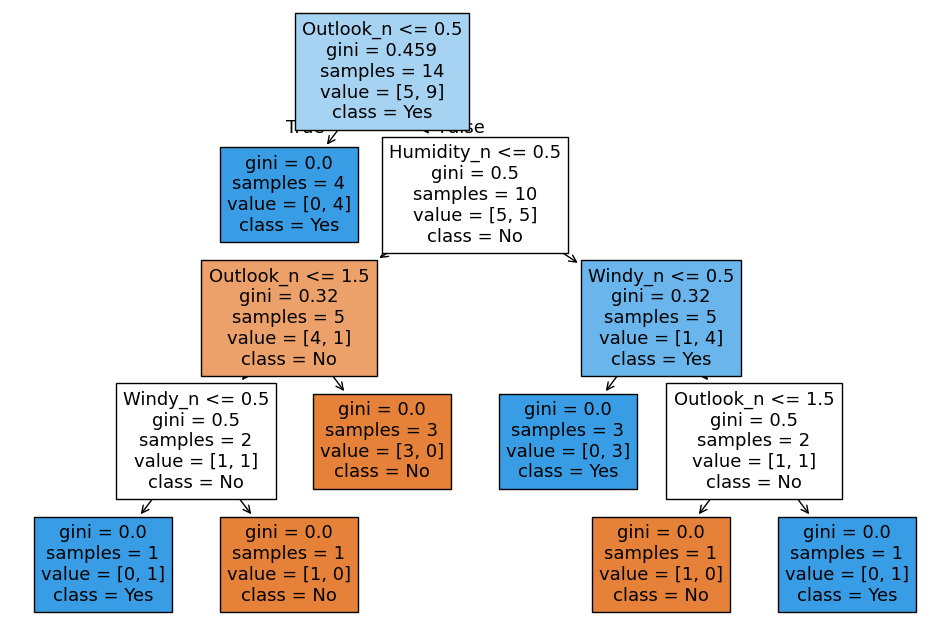

In [53]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(
    model,
    feature_names=x.columns,
    class_names=['No','Yes'],
    filled=True
)
plt.show()